question 8 
Degree 1 MSE: 5.618654575110989
Degree 2 MSE: 5.606472450872898
Degree 3 MSE: 5.607489164864765
question 9
Final weights: [-3.000e-03 -7.305e-01  4.541e-02 -4.675e+02]
Final weights: [-1.5000e-02 -3.6525e+00  2.2705e-01 -2.3375e+03]


/tmp/ipython-input-287965519.py:43: RuntimeWarning: overflow encountered in exp
  def sigmoid(z): return 1/(1+np.exp(-z))


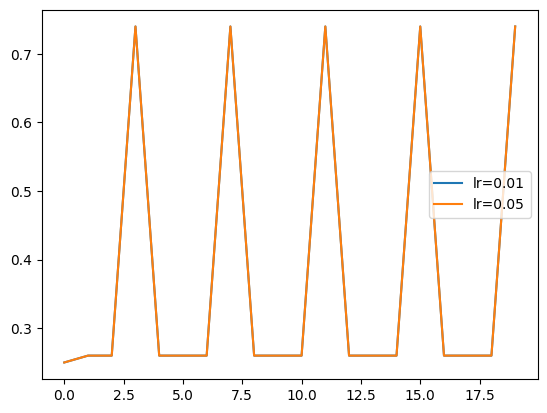

question 10


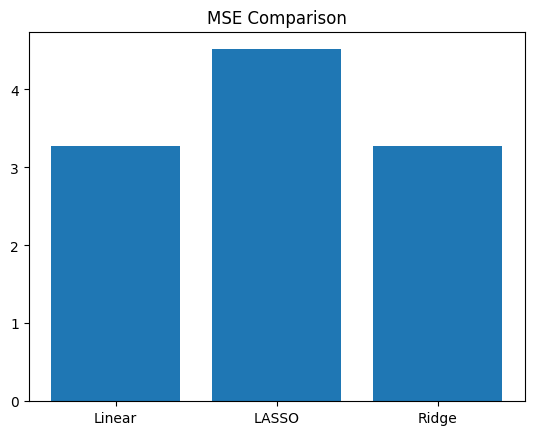

In [10]:


#QUESTION 8
print("question 8 ")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate data
X = np.linspace(0,10,100).reshape(-1,1)
y = 3*X.squeeze()+5+np.random.normal(0,2,100)

Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2)

for d in [1,2,3]:
    poly=PolynomialFeatures(d)
    Xtr_p=poly.fit_transform(Xtr)
    Xte_p=poly.transform(Xte)

    model=LinearRegression()
    model.fit(Xtr_p,ytr)

    pred=model.predict(Xte_p)
    print(f"Degree {d} MSE:",mean_squared_error(yte,pred))


#quesiton 9
print("question 9")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data=pd.read_csv("A2_P2.csv")
X=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

X=np.c_[np.ones(len(X)),X]
w=np.zeros(X.shape[1])

def sigmoid(z): return 1/(1+np.exp(-z))

for lr in [0.01,0.05]:
    w=np.zeros(X.shape[1])
    mse_list=[]

    for _ in range(20):
        yhat=sigmoid(X@w)
        grad=X.T@(yhat-y)/len(y)
        w-=lr*grad
        mse_list.append(np.mean((y-yhat)**2))

    plt.plot(mse_list,label=f"lr={lr}")
    print("Final weights:",w)

plt.legend(); plt.show()

#question 10
print("question 10")

import pandas as pd
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

data=pd.read_csv("A2_P3.csv")

X=data.iloc[:,:-1]
y=data.iloc[:,-1]

Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2)

models={
"Linear":LinearRegression(),
"LASSO":Lasso(alpha=0.5),
"Ridge":Ridge(alpha=0.1)
}

mse=[]
coefs=[]

for name,m in models.items():
    m.fit(Xtr,ytr)
    pred=m.predict(Xte)
    mse.append(mean_squared_error(yte,pred))
    coefs.append(m.coef_)

plt.bar(models.keys(),mse)
plt.title("MSE Comparison")
plt.show()
